<a href="https://colab.research.google.com/github/luizby20/Practica-2/blob/main/10%20Proyecci%C3%B3n%20de%20imagen/Practica_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -nc 'https://raw.githubusercontent.com/Jegovila/SSPIA1/main/10%20Proyecci%C3%B3n%20de%20imagen/A.bmp'
!wget -nc 'https://raw.githubusercontent.com/Jegovila/SSPIA1/main/10%20Proyecci%C3%B3n%20de%20imagen/B.bmp'

import cv2
import numpy as np
import matplotlib.pyplot as plt
import imutils
from google.colab.patches import cv2_imshow

--2026-04-20 05:13:03--  https://raw.githubusercontent.com/Jegovila/SSPIA1/main/10%20Proyecci%C3%B3n%20de%20imagen/A.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2986030 (2.8M) [image/bmp]
Saving to: ‘A.bmp’

A.bmp               100%[===================>]   2.85M  --.-KB/s    in 0.07s   

2026-04-20 05:13:04 (42.7 MB/s) - ‘A.bmp’ saved [2986030/2986030]

--2026-04-20 05:13:04--  https://raw.githubusercontent.com/Jegovila/SSPIA1/main/10%20Proyecci%C3%B3n%20de%20imagen/B.bmp
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 286

# Funciones

## Extraer puntos

In [2]:
def Extraer_Puntos(ImgA, ImgB):
    akaze = cv2.AKAZE_create()
    kpts1, desc1 = akaze.detectAndCompute(ImgA, None)
    kpts2, desc2 = akaze.detectAndCompute(ImgB, None)

    matcher = cv2.DescriptorMatcher_create(cv2.DescriptorMatcher_BRUTEFORCE_HAMMING)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)
    nn_matches = bf.match(desc1, desc2)

    # good = []

    # for m, n in nn_matches:
    #     if m.distance < 0.9 * n.distance:
    #         good.append([m])

    good = sorted(nn_matches, key=lambda x: x.distance)
    im3 = cv2.drawMatches(ImgA, kpts1, ImgB, kpts2, good[:50], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    cv2_imshow(im3)

    pointsImgA = np.empty([len(good), 2])
    pointsImgB = np.empty([len(good), 2])


    for i in range(len(good)):
        pointsImgA[i, :] = kpts1[good[i].queryIdx].pt
        pointsImgB[i, :] = kpts2[good[i].trainIdx].pt

    return pointsImgA[:600], pointsImgB[:600]

## Desplegar imágenes

In [3]:

def plot_images(*imgs, figsize=(10,5), hide_ticks=False):
    '''Display one or multiple images.'''
    f = plt.figure(figsize=figsize)
    width = np.ceil(np.sqrt(len(imgs))).astype('int')
    height = np.ceil(len(imgs) / width).astype('int')
    for i, img in enumerate(imgs, 1):
        ax = f.add_subplot(height, width, i)
        if hide_ticks:
            ax.axis('off')
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

## Crear Panorama

In [4]:
def Crear_Figura_Panoramica(ImgA, ImgB, T):
    dim_x = ImgA.shape[0] + ImgB.shape[0]
    dim_y = ImgA.shape[1] + ImgB.shape[1]
    dim = (dim_x, dim_y)

    warped = cv2.warpPerspective(ImgB, T, dim)

    #plot_images(warped)
    comb = warped.copy()

    # combinar las dos imagenes
    comb[0:ImgA.shape[0], 0:ImgA.shape[1]] = ImgA

    # crop (Recortar al tamaño de la imagen de salida)
    gray = cv2.cvtColor(comb, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY)[1]

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)

    c = max(cnts, key=cv2.contourArea)

    (x, y, w, h) = cv2.boundingRect(c)

    comb = comb[y:y + h, x:x + w]
    plot_images(comb)
    plt.show()

## Construir Matriz de transformación

In [5]:
def Construir_Matriz_Transformacion(x):
    T = np.array([[x[0], x[1], x[2]], [x[3], x[4], x[5]], [x[6], x[7], x[8]]])
    return T

## Cálculo del error

In [6]:
def Calcular_Errores(pA, ppB):
    ppB = ppB.transpose()
    e = np.sqrt((pA[:, 0] - ppB[:, 0]) ** 2 + (pA[:, 1] - ppB[:, 1]) ** 2)
    return e

## Transformar Puntos

In [7]:
def Transformar_Puntos(p, T):
    p2 = np.empty([len(p), 2])
    for i in range(len(p)):
        p2[i, :] = p[i]

    P = np.concatenate((p2, np.ones([len(p),1])),1) @ T.transpose()
    pp = np.array([P[:, 0] / P[:, 2], P[:, 1] / P[:, 2]])

    return pp

# Algoritmo

Leer imágenes y extraer puntos de interés

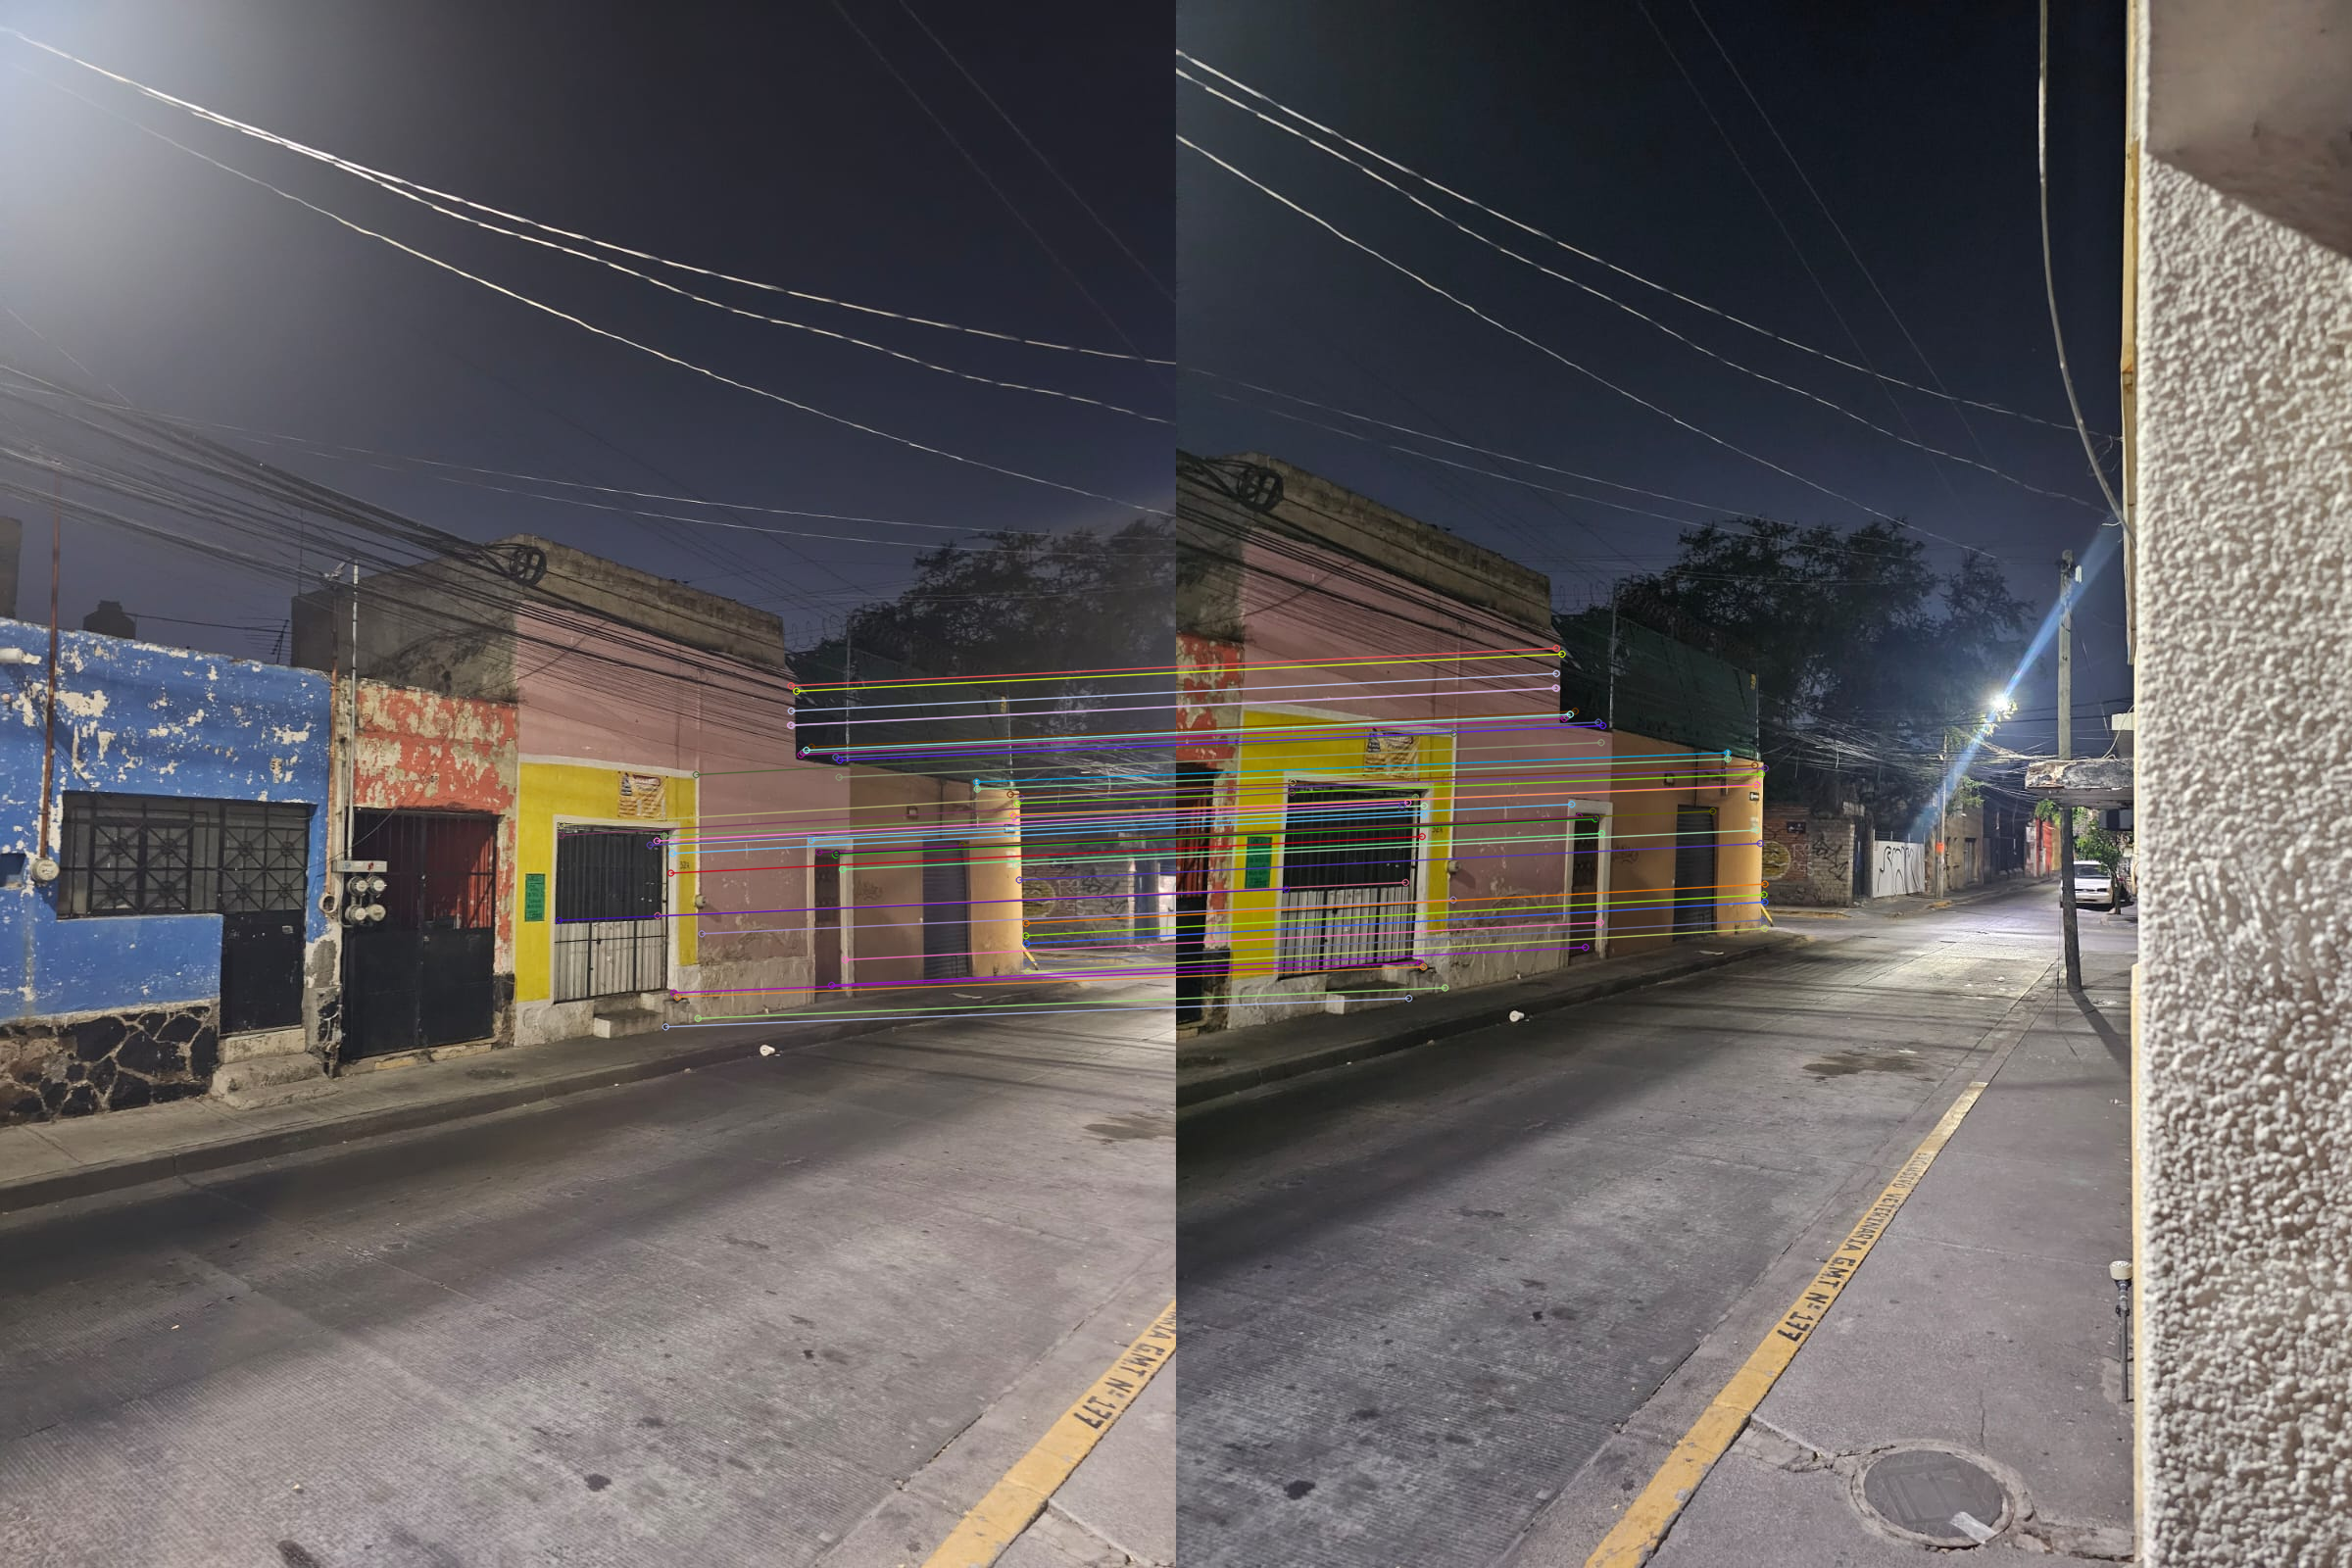

In [9]:
ImgA = cv2.imread('115371.jpg')
ImgB = cv2.imread('115372.jpg')

pA, pB = Extraer_Puntos(ImgA, ImgB)

Parámetros

In [13]:
M = len(pB)
l = 0.01    # Parámetro de regularización

# AUMENTAMOS SIGNIFICATIVAMENTE PARA ASEGURAR CONVERGENCIA
G = 500     # Generaciones (antes 250)
N = 150     # Tamaño de la población (antes 60)

F = 0.6     # Factor de mutación
CR = 0.8    # Tasa de cruza

D = 9       # Dimensión del problema

# Límites inferior y superior (ampliados para fotos de alta resolución)
xl = np.array([-2.0, -2.0, -5000.0, -2.0, -2.0, -5000.0, -0.01, -0.01, -2.0])
xu = np.array([ 2.0,  2.0,  5000.0,  2.0,  2.0,  5000.0,  0.01,  0.01,  2.0])

x = np.zeros((D, N))
fitness = np.zeros(N)
fx_plot = np.zeros(G)

Algoritmo de optimización

Inicializando la población...
Iniciando optimización para 500 generaciones (esto tomará un tiempo)...
Generación 50/500 - Fitness actual: -229945.8741
Generación 100/500 - Fitness actual: -44583093535.6864
Generación 150/500 - Fitness actual: -1052194691427131.6250
Generación 200/500 - Fitness actual: -15174794574040756224.0000
Generación 250/500 - Fitness actual: -328574903495314831835136.0000
Generación 300/500 - Fitness actual: -7255918407543031711190220800.0000
Generación 350/500 - Fitness actual: -276448088864852571422193883283456.0000
Generación 400/500 - Fitness actual: -28189698246937190481647434749871915008.0000
Generación 450/500 - Fitness actual: -3678892838743590609312486891373812298809344.0000
Generación 500/500 - Fitness actual: -186718470229914620741371987263711033875331284992.0000
Optimización completada en 57.8 segundos.

--- RESULTADOS ---
Matriz de Transformación Óptima:
[[-3.52132430e+49 -2.21818562e+49 -1.95653392e+48]
 [ 8.21489041e+47 -3.37899414e+48 -2.25405609e

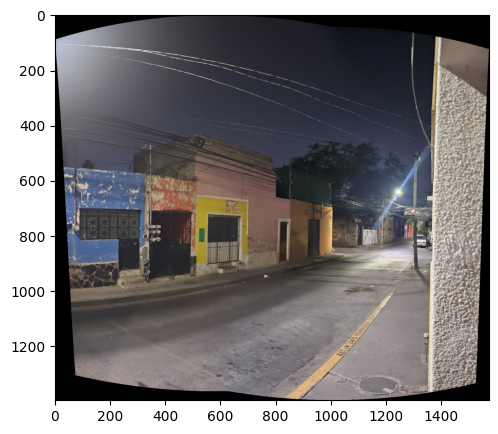

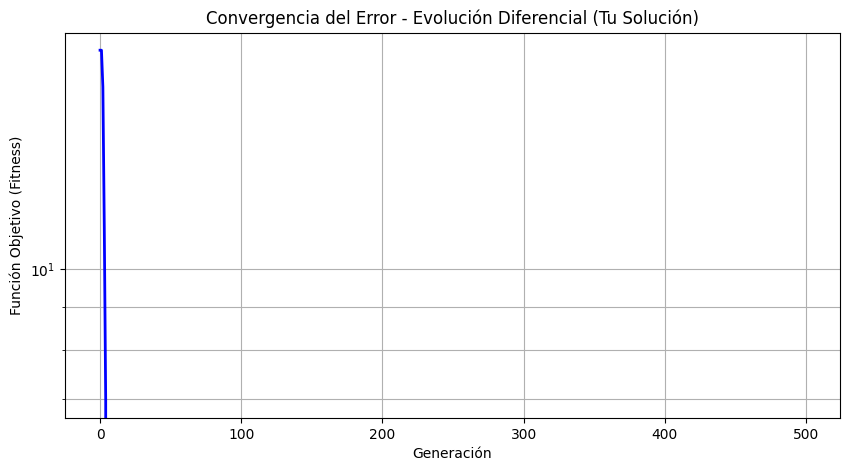

In [14]:
import time

# --- 1. Inicialización ---
print("Inicializando la población...")
for i in range(N):
    x[:, i] = xl + (xu - xl) * np.random.rand(D)
    T = Construir_Matriz_Transformacion(x[:, i])
    ppB = Transformar_Puntos(pB, T)
    e = Calcular_Errores(pA, ppB)
    fitness[i] = np.sqrt(np.mean(e * 2)) + l * (1/D) * np.sum(x[:,i] * 2)

# --- 2. Algoritmo de optimización ---
print(f"Iniciando optimización para {G} generaciones (esto tomará un tiempo)...")
start_time = time.time()

for n in range(G):
    if (n + 1) % 50 == 0:
        print(f"Generación {n+1}/{G} - Fitness actual: {np.min(fitness):.4f}")

    for i in range(N):
        # Mutación DE/rand/1
        I = np.random.permutation(N)
        I = np.delete(I, [np.where(I == i)[0][0]])
        r1, r2, r3 = I[0], I[1], I[2]
        v = x[:, r1] + F * (x[:, r2] - x[:, r3])

        # Recombinación
        u = np.zeros(D)
        k = np.random.randint(D)
        for j in range(D):
            if np.random.rand() <= CR or k == j:
                u[j] = v[j].copy()
            else:
                u[j] = x[j, i].copy()


        T_u = Construir_Matriz_Transformacion(u)
        ppB_u = Transformar_Puntos(pB, T_u)
        e_u = Calcular_Errores(pA, ppB_u)
        fitness_u = np.sqrt(np.mean(e_u * 2)) + l * (1/D) * np.sum(u * 2)

        if fitness_u < fitness[i]:
            x[:, i] = u
            fitness[i] = fitness_u

    fx_plot[n] = np.min(fitness)

end_time = time.time()
print(f"Optimización completada en {end_time - start_time:.1f} segundos.")

igb = np.argmin(fitness)
T_opt = Construir_Matriz_Transformacion(x[:, igb])

print("\n--- RESULTADOS ---")
print("Matriz de Transformación Óptima:")
print(T_opt)


print("Generando el panorama fusionado...")


images = [ImgA, ImgB]
stitcher = cv2.Stitcher_create(cv2.Stitcher_PANORAMA)
(status, panorama_opencv) = stitcher.stitch(images)

if status == cv2.Stitcher_OK:
    print("Panorama fusionado exitosamente.")
    plot_images(panorama_opencv)
    plt.show()
else:
    print(f"Falló la fusión automática de OpenCV ({status}). Generando el panorama básico...")
    Crear_Figura_Panoramica(ImgA, ImgB, T_opt)

# Graficar la convergencia del error
plt.figure(figsize=(10, 5))
plt.plot(fx_plot, color='blue', linewidth=2)
plt.title('Convergencia del Error - Evolución Diferencial (Tu Solución)')
plt.xlabel('Generación')
plt.ylabel('Función Objetivo (Fitness)')
plt.yscale('log') # Escala logarítmica para ver mejor el cambio
plt.grid(True, which="both", ls="-")
plt.show()